# 02 — Exploratory Data Analysis (EDA)


Perform detailed exploratory data analysis.

Generate descriptive statistics. 

Create visualizations to identify trends, correlations, and anomalies. 

Highlight key operational and customer insights



## EDA Structure

<table>
  <thead><tr><th>Section</th><th>Topic</th></tr></thead>
  <tbody>
    <tr><td>1</td><td>Setup &amp; Load Data</td></tr>
    <tr><td>2</td><td>Descriptive Statistics</td></tr>
    <tr><td>3</td><td>Revenue Trends (Time Series)</td></tr>
    <tr><td>4</td><td>Product Analysis</td></tr>
    <tr><td>5</td><td>Customer Analysis</td></tr>
    <tr><td>6</td><td>Geographic Analysis</td></tr>
    <tr><td>7</td><td>Correlation Analysis</td></tr>
    <tr><td>8</td><td>Anomaly Detection</td></tr>
    <tr><td>9</td><td>Key Business Insights Summary</td></tr>
  </tbody>
</table>

---
## Section 1 — Setup & Load Cleaned Data

In [49]:
# ============================================================
# SECTION 1: SETUP & LOAD DATA
# FIX 1: Replaced hardcoded Windows path with relative path
# FIX 2: Added feature engineering (DayOfWeek, Hour, Month, Year)
# FIX 3: Added missing value check
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
})

# ── Paths (relative — works for all team members) ────────────
# notebooks/ is the current working directory
# data/ and reports/ are siblings of notebooks/ inside group-assignment/
NOTEBOOK_DIR   = os.getcwd()                          # .../group-assignment/notebooks
PROJECT_ROOT   = os.path.dirname(NOTEBOOK_DIR)        # .../group-assignment
DATA_FOLDER    = os.path.join(PROJECT_ROOT, 'data')
REPORTS_FOLDER = os.path.join(PROJECT_ROOT, 'reports')
DATA_FILE      = os.path.join(DATA_FOLDER, 'cleaned_retail_data.csv')
os.makedirs(REPORTS_FOLDER, exist_ok=True)

# ── Load cleaned data from ETL ───────────────────────────────
df = pd.read_csv(DATA_FILE)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# ── Feature Engineering (required for Sections 2-9) ─────────
df['Month']     = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour']      = df['InvoiceDate'].dt.hour
df['Year']      = df['InvoiceDate'].dt.year

# Detect customer column name (handles both naming conventions)
customer_col = 'Customer ID' if 'Customer ID' in df.columns else 'CustomerID'
invoice_col  = 'Invoice'     if 'Invoice'     in df.columns else 'InvoiceNo'

print('Dataset loaded successfully!')
print(f'Shape   : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Columns : {list(df.columns)}')
print()

# ── Missing value check ──────────────────────────────────────
print('=== MISSING VALUES PER COLUMN ===')
missing = df.isnull().sum()
print(missing.to_string())
print(f'\nTotal missing cells : {df.isnull().sum().sum()}')
print()

display(df.head())

Dataset loaded successfully!
Shape   : 333,234 rows  x  13 columns
Columns : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Total_Revenue', 'Month', 'DayOfWeek', 'Hour', 'Year']

=== MISSING VALUES PER COLUMN ===
Invoice          0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
Price            0
Customer ID      0
Country          0
Total_Revenue    0
Month            0
DayOfWeek        0
Hour             0
Year             0

Total missing cells : 0



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Revenue,Month,DayOfWeek,Hour,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,Wednesday,8,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,Wednesday,8,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,Wednesday,8,2010


---
## Section 2 — Descriptive Statistics

Descriptive statistics summarise the central tendency, dispersion, and shape of the dataset's distributions.

In [50]:
# ============================================================
# SECTION 2A: OVERALL DATASET STATISTICS
# ============================================================
print('=== DATASET OVERVIEW ===')
print(f'  Total transactions    : {len(df):,}')
print(f'  Unique invoices       : {df[invoice_col].nunique():,}')
print(f'  Unique customers      : {df[customer_col].nunique():,}')
print(f'  Unique products       : {df["StockCode"].nunique():,}')
print(f'  Unique countries      : {df["Country"].nunique()}')
print(f'  Date range            : {df["InvoiceDate"].min().date()}  to  {df["InvoiceDate"].max().date()}')
print(f'  Total Revenue (GBP)   : £{df["Total_Revenue"].sum():,.2f}')
print(f'  Avg Revenue/Invoice   : £{df.groupby(invoice_col)["Total_Revenue"].sum().mean():,.2f}')
print()

=== DATASET OVERVIEW ===
  Total transactions    : 333,234
  Unique invoices       : 16,826
  Unique customers      : 4,191
  Unique products       : 3,392
  Unique countries      : 37
  Date range            : 2010-12-01  to  2011-12-09
  Total Revenue (GBP)   : £4,299,476.18
  Avg Revenue/Invoice   : £255.53



In [51]:
# ============================================================
# SECTION 2B: NUMERICAL DESCRIPTIVE STATISTICS
# ============================================================
print('=== NUMERICAL DESCRIPTIVE STATISTICS ===')
num_stats = df[['Quantity', 'Price', 'Total_Revenue']].describe().T
num_stats['cv%']      = (num_stats['std'] / num_stats['mean'] * 100).round(2)
num_stats['skew']     = df[['Quantity', 'Price', 'Total_Revenue']].skew().values
num_stats['kurtosis'] = df[['Quantity', 'Price', 'Total_Revenue']].kurtosis().values
display(num_stats.round(3))

print()
print('Interpretation:')
print('  Coefficient of Variation (cv%) measures relative spread — higher = more variable')
print('  Skew > 0 = right-skewed (tail towards high values)')
print('  Kurtosis > 3 = heavy-tailed (more extreme values than normal distribution)')

=== NUMERICAL DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max,cv%,skew,kurtosis
Quantity,333234.0,7.551,6.777,1.000,2.00,6.00,12.00,27.0,89.76,1.192,0.617
Price,333234.0,2.194,1.546,0.001,1.25,1.65,2.95,7.5,70.46,1.087,0.585
Total_Revenue,333234.0,12.902,13.215,0.001,3.90,10.14,17.40,178.8,102.42,3.250,18.106



Interpretation:
  Coefficient of Variation (cv%) measures relative spread — higher = more variable
  Skew > 0 = right-skewed (tail towards high values)
  Kurtosis > 3 = heavy-tailed (more extreme values than normal distribution)


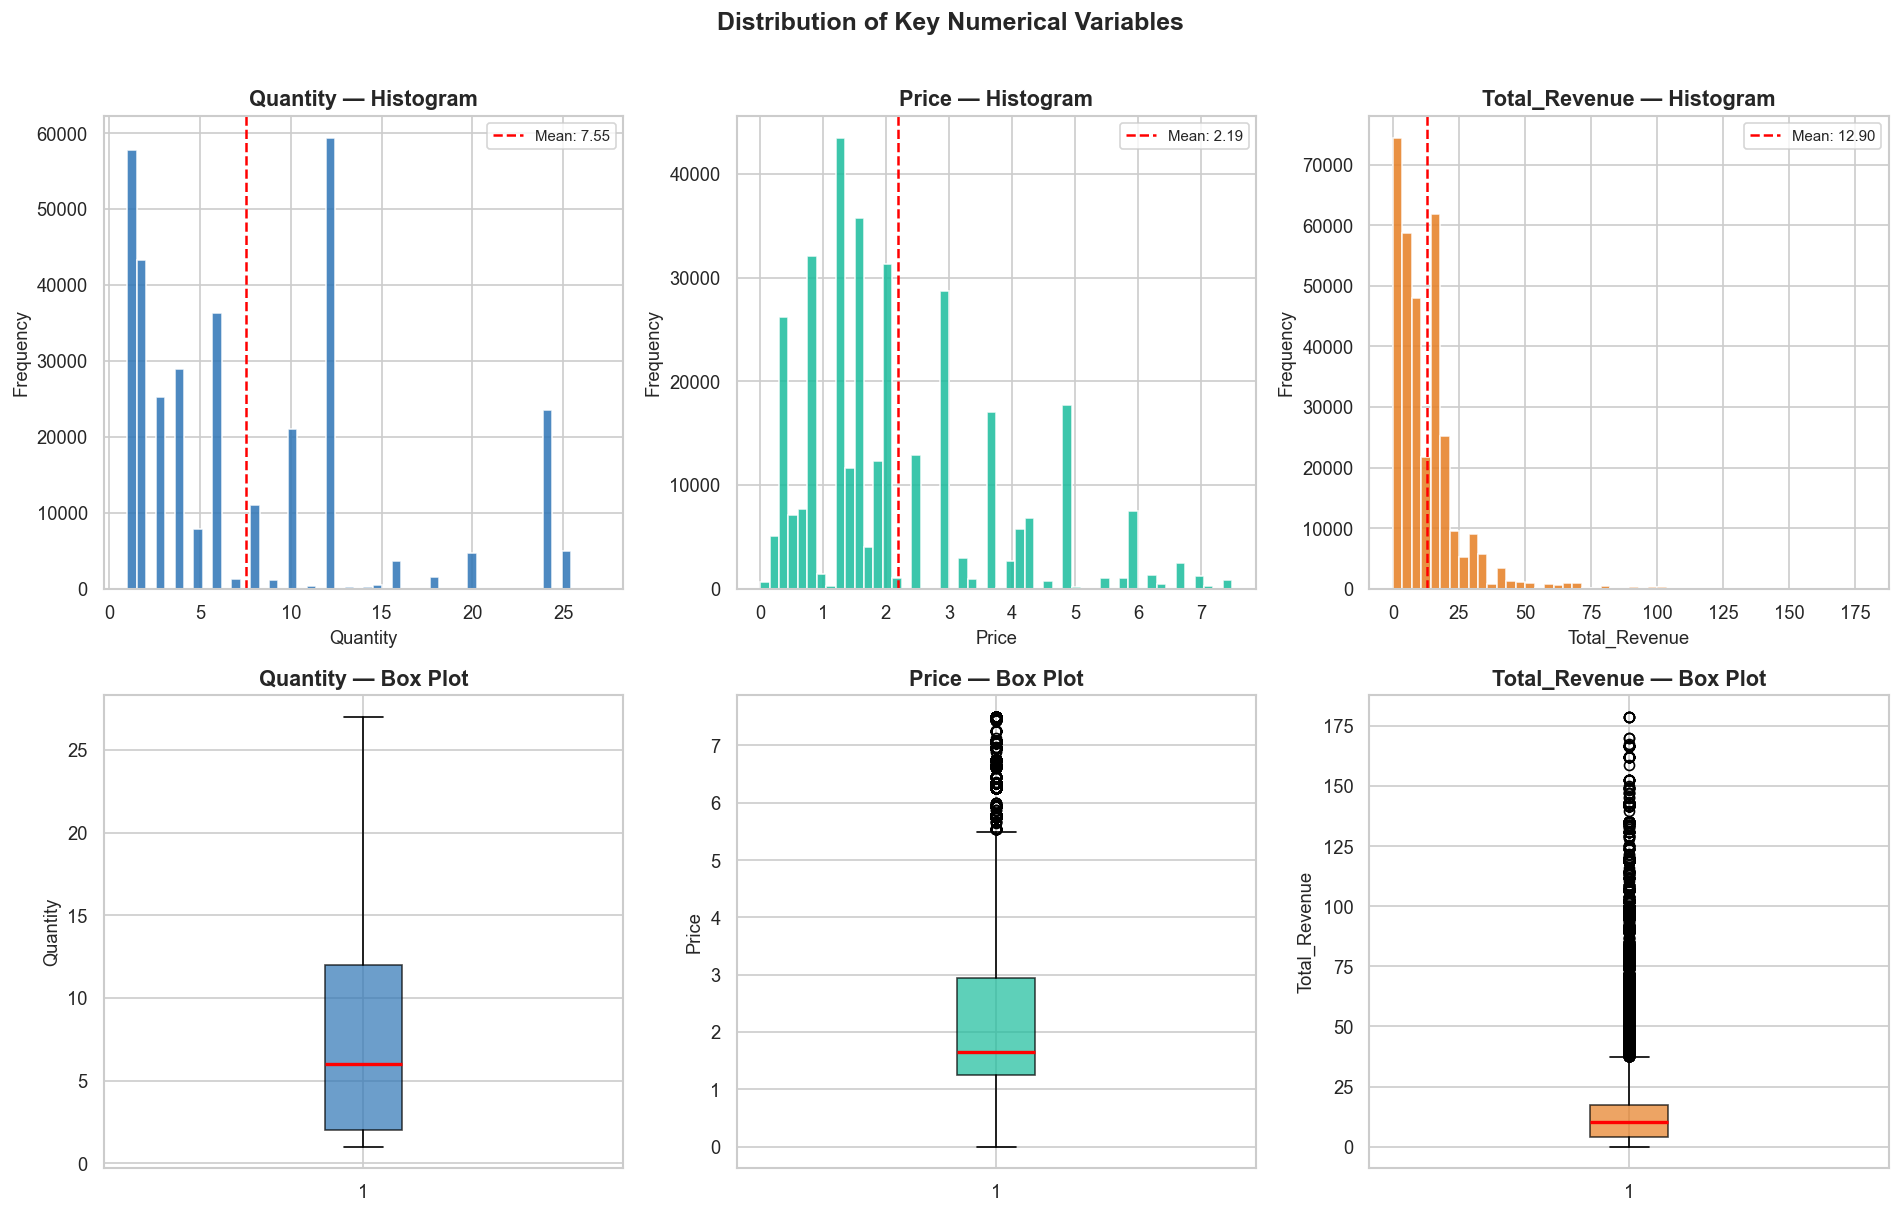

Chart saved: eda_distributions.png


In [52]:
# ============================================================
# SECTION 2C: DISTRIBUTION PLOTS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cols   = ['Quantity', 'Price', 'Total_Revenue']
colors = ['#2E75B6', '#1ABC9C', '#E67E22']

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[0, i].hist(df[col], bins=50, color=color, edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col} — Histogram')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    mean_val = df[col].mean()
    axes[0, i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes[0, i].legend(fontsize=9)

    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} — Box Plot')
    axes[1, i].set_ylabel(col)

plt.suptitle('Distribution of Key Numerical Variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: eda_distributions.png')

In [53]:
# ============================================================
# SECTION 2D: CATEGORICAL VARIABLE STATISTICS
# ============================================================
print('=== TOP 10 COUNTRIES BY TRANSACTION COUNT ===')
print(df['Country'].value_counts().head(10).to_string())
print()
print('=== DAY-OF-WEEK BY TRANSACTION COUNT ===')
day_order_full = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = df['DayOfWeek'].value_counts().reindex(day_order_full).dropna()
print(day_counts.to_string())
print()
print('=== TRANSACTIONS BY HOUR (TOP 5) ===')
print(df['Hour'].value_counts().head(5).sort_index().to_string())

=== TOP 10 COUNTRIES BY TRANSACTION COUNT ===
Country
United Kingdom    300281
Germany             7448
France              6890
EIRE                5443
Spain               2040
Belgium             1660
Switzerland         1433
Portugal            1252
Norway               772
Netherlands          617

=== DAY-OF-WEEK BY TRANSACTION COUNT ===
DayOfWeek
Monday       54603.0
Tuesday      55371.0
Wednesday    56836.0
Thursday     66109.0
Friday       45865.0
Sunday       54450.0

=== TRANSACTIONS BY HOUR (TOP 5) ===
Hour
11    40950
12    61040
13    54492
14    46046
15    38301


---
## Section 3 — Revenue Trends (Time Series Analysis)

Time series analysis reveals seasonal patterns, growth trends, and demand cycles.

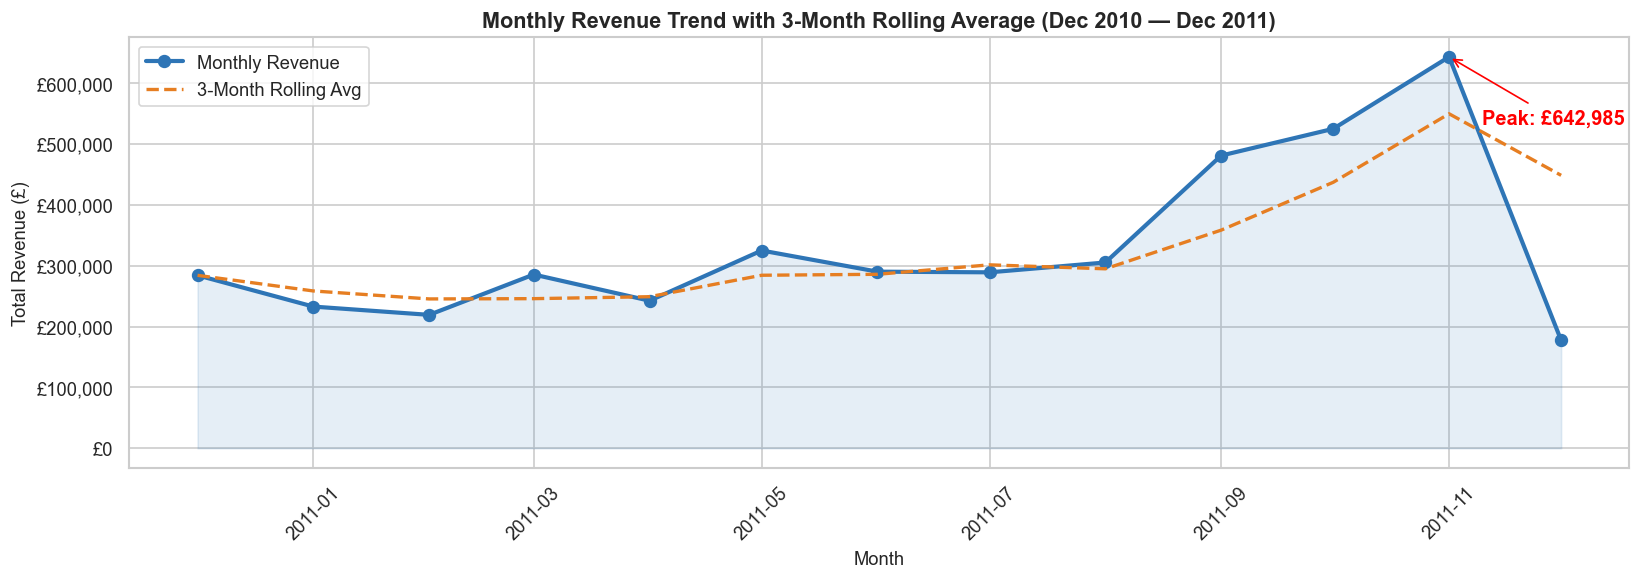

Peak revenue month  : November 2011  (£642,984.88)
Lowest revenue month: December 2011
Insight: Revenue peaks in Q4 (Oct-Nov) — consistent with pre-Christmas gift purchasing demand.
Insight: The rolling average confirms a steady upward trend across the full year.


In [54]:
# ============================================================
# SECTION 3A: MONTHLY REVENUE TREND
# ADDITION: 3-month rolling average line added to smooth trend
# ============================================================
monthly_rev = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Total_Revenue'].sum().reset_index()
monthly_rev['InvoiceDate'] = monthly_rev['InvoiceDate'].dt.to_timestamp()

# Rolling average (3-month window)
monthly_rev['Rolling_Avg'] = monthly_rev['Total_Revenue'].rolling(window=3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_rev['InvoiceDate'], monthly_rev['Total_Revenue'],
        marker='o', color='#2E75B6', linewidth=2.5, markersize=7, label='Monthly Revenue')
ax.fill_between(monthly_rev['InvoiceDate'], monthly_rev['Total_Revenue'],
                alpha=0.12, color='#2E75B6')
# Rolling average overlay
ax.plot(monthly_rev['InvoiceDate'], monthly_rev['Rolling_Avg'],
        color='#E67E22', linewidth=2, linestyle='--', label='3-Month Rolling Avg')

peak_idx = monthly_rev['Total_Revenue'].idxmax()
ax.annotate(f'Peak: £{monthly_rev.loc[peak_idx,"Total_Revenue"]:,.0f}',
            xy=(monthly_rev.loc[peak_idx,'InvoiceDate'], monthly_rev.loc[peak_idx,'Total_Revenue']),
            xytext=(20, -40), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontweight='bold')
ax.set_title('Monthly Revenue Trend with 3-Month Rolling Average (Dec 2010 — Dec 2011)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_monthly_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

peak_month = monthly_rev.loc[peak_idx, 'InvoiceDate'].strftime('%B %Y')
print(f'Peak revenue month  : {peak_month}  (£{monthly_rev.loc[peak_idx,"Total_Revenue"]:,.2f})')
print(f'Lowest revenue month: {monthly_rev.loc[monthly_rev["Total_Revenue"].idxmin(),"InvoiceDate"].strftime("%B %Y")}')
print('Insight: Revenue peaks in Q4 (Oct-Nov) — consistent with pre-Christmas gift purchasing demand.')
print('Insight: The rolling average confirms a steady upward trend across the full year.')

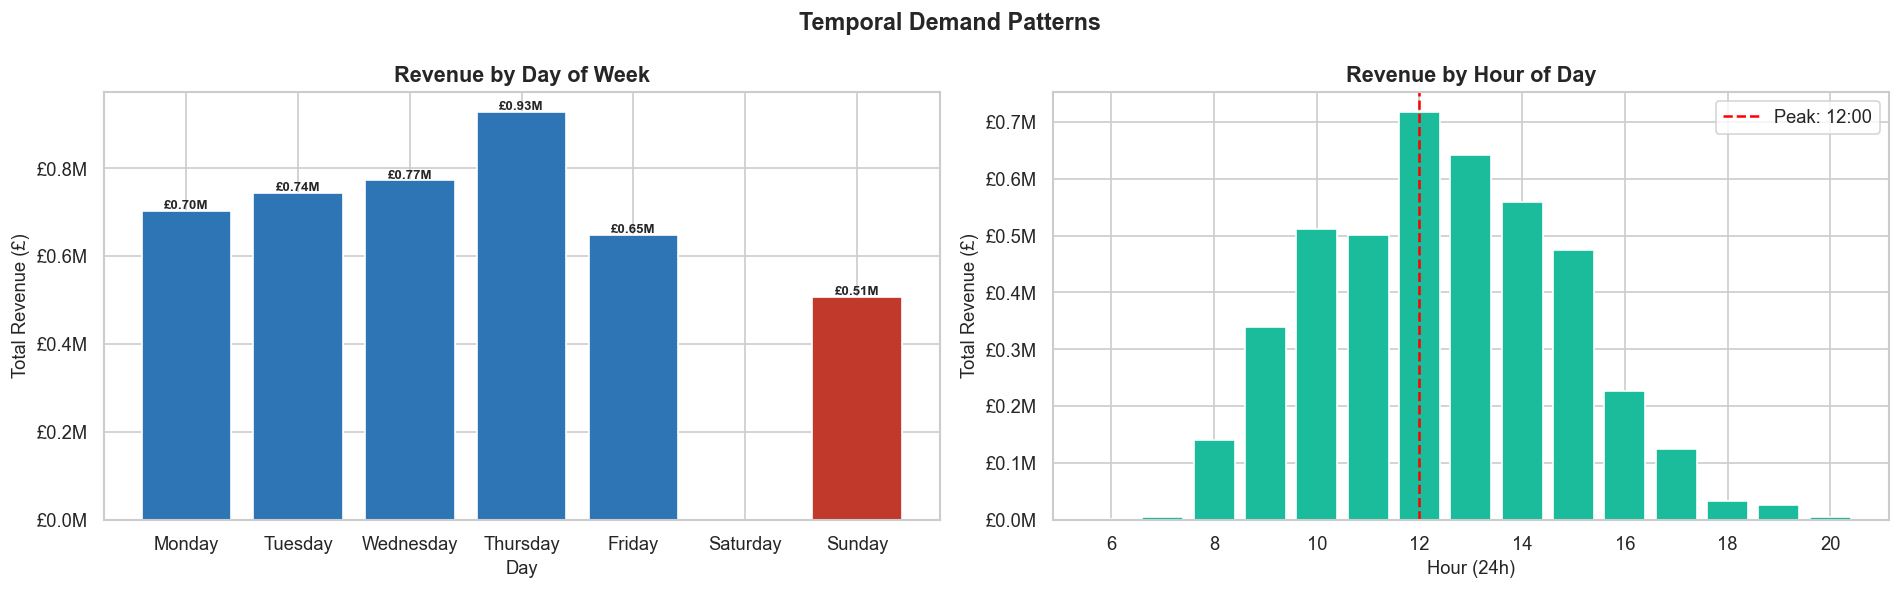

Peak day   : Thursday  (£927,269)
Lowest day : Sunday  (£506,286)
Peak hour  : 12:00
Insight: Thursday is the highest revenue day. Most purchases occur between 10am-3pm.


In [55]:
# ============================================================
# SECTION 3B: REVENUE BY DAY OF WEEK & HOUR
# ============================================================
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_rev   = df.groupby('DayOfWeek')['Total_Revenue'].sum().reindex(day_order)
hour_rev  = df.groupby('Hour')['Total_Revenue'].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_colors = ['#C0392B' if d == 'Sunday' else '#2E75B6' for d in day_order]
axes[0].bar(day_rev.index, day_rev.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].set_xlabel('Day')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
for i, v in enumerate(day_rev.values):
    if not np.isnan(v):
        axes[0].text(i, v + 5000, f'£{v/1e6:.2f}M', ha='center', fontsize=8, fontweight='bold')

axes[1].bar(hour_rev.index, hour_rev.values, color='#1ABC9C', edgecolor='white')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].set_xlabel('Hour (24h)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
peak_hour = hour_rev.idxmax()
axes[1].axvline(peak_hour, color='red', linestyle='--', linewidth=1.5, label=f'Peak: {peak_hour}:00')
axes[1].legend()

plt.suptitle('Temporal Demand Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_temporal_patterns.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak day   : {day_rev.idxmax()}  (£{day_rev.max():,.0f})')
print(f'Lowest day : {day_rev.idxmin()}  (£{day_rev.min():,.0f})')
print(f'Peak hour  : {peak_hour}:00')
print('Insight: Thursday is the highest revenue day. Most purchases occur between 10am-3pm.')

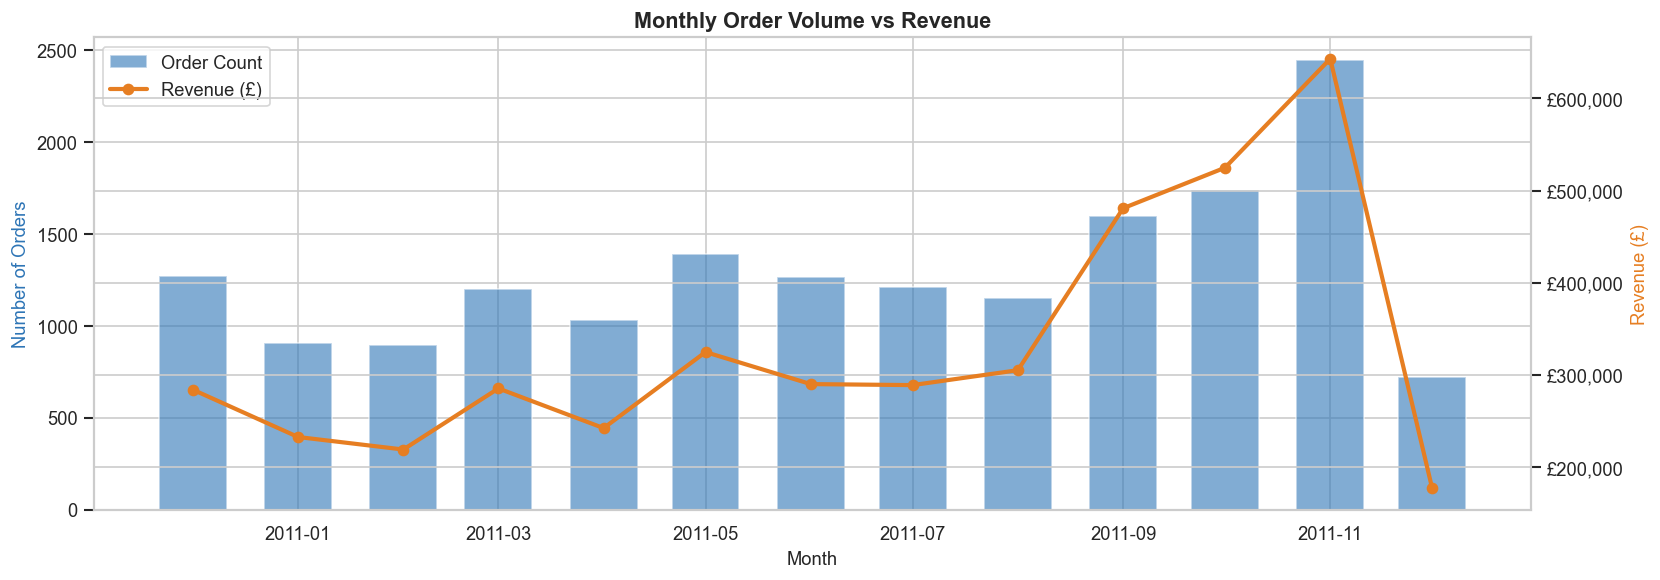

Insight: Order volume and revenue are highly correlated. Seasonal spikes align in Oct-Nov.


In [56]:
# ============================================================
# SECTION 3C: MONTHLY ORDER VOLUME vs REVENUE
# ============================================================
monthly_orders = df.groupby(df['InvoiceDate'].dt.to_period('M')).agg(
    Revenue = ('Total_Revenue', 'sum'),
    Orders  = (invoice_col, 'nunique')
).reset_index()
monthly_orders['InvoiceDate'] = monthly_orders['InvoiceDate'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly_orders['InvoiceDate'], monthly_orders['Orders'],
        width=20, color='#2E75B6', alpha=0.6, label='Order Count')
ax2.plot(monthly_orders['InvoiceDate'], monthly_orders['Revenue'],
         marker='o', color='#E67E22', linewidth=2.5, label='Revenue (£)')

ax1.set_ylabel('Number of Orders', color='#2E75B6')
ax2.set_ylabel('Revenue (£)', color='#E67E22')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax1.set_title('Monthly Order Volume vs Revenue')
ax1.set_xlabel('Month')
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_orders_vs_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Order volume and revenue are highly correlated. Seasonal spikes align in Oct-Nov.')

---
## Section 4 — Product Analysis

Identifying top-performing and underperforming products to support inventory and marketing decisions.

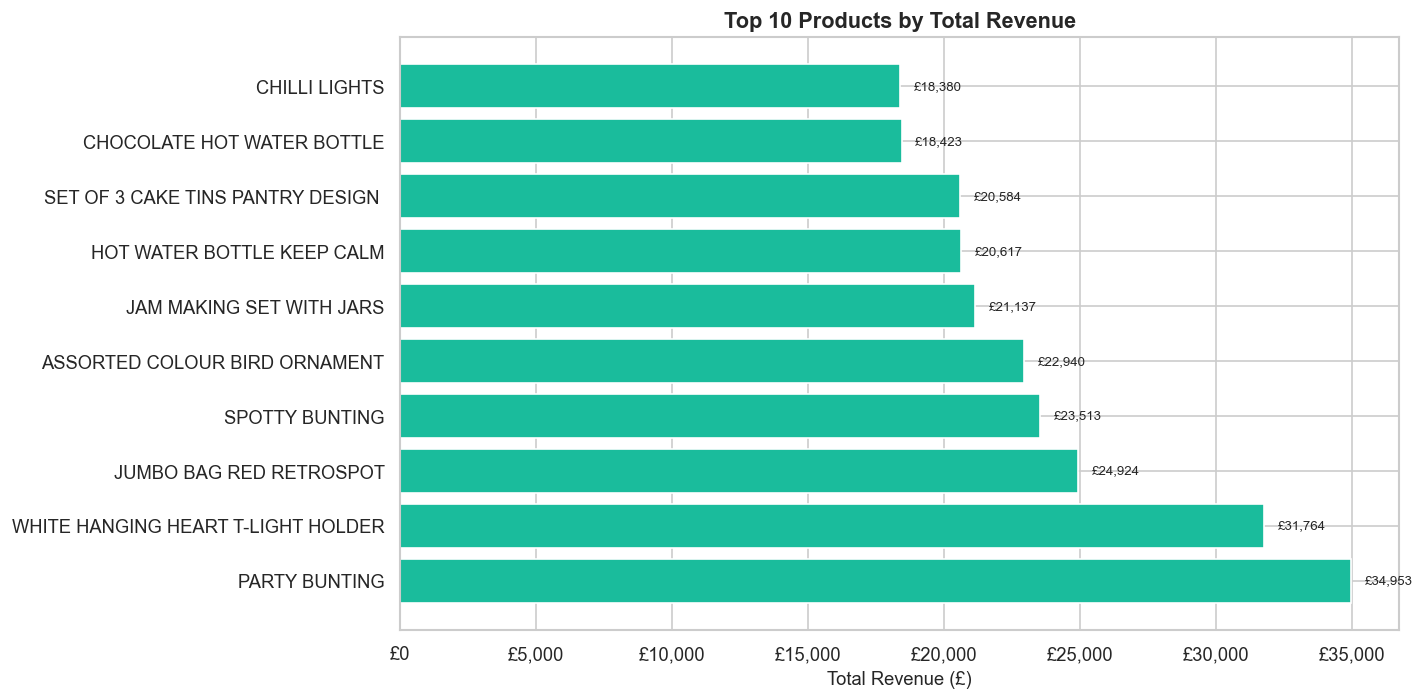

Top 10 Products by Revenue:
                       Description  Total_Revenue
                     PARTY BUNTING       34952.85
WHITE HANGING HEART T-LIGHT HOLDER       31763.76
           JUMBO BAG RED RETROSPOT       24923.50
                    SPOTTY BUNTING       23513.05
     ASSORTED COLOUR BIRD ORNAMENT       22940.06
          JAM MAKING SET WITH JARS       21137.25
        HOT WATER BOTTLE KEEP CALM       20617.35
 SET OF 3 CAKE TINS PANTRY DESIGN        20583.97
        CHOCOLATE HOT WATER BOTTLE       18422.85
                     CHILLI LIGHTS       18379.80


In [57]:
# ============================================================
# SECTION 4A: TOP 10 PRODUCTS BY REVENUE
# ============================================================
top_products = (df.groupby('Description')['Total_Revenue']
                  .sum()
                  .nlargest(10)
                  .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_products['Description'], top_products['Total_Revenue'],
               color='#1ABC9C', edgecolor='white')
ax.set_title('Top 10 Products by Total Revenue')
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, top_products['Total_Revenue']):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_top_products_revenue.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Products by Revenue:')
print(top_products.to_string(index=False))

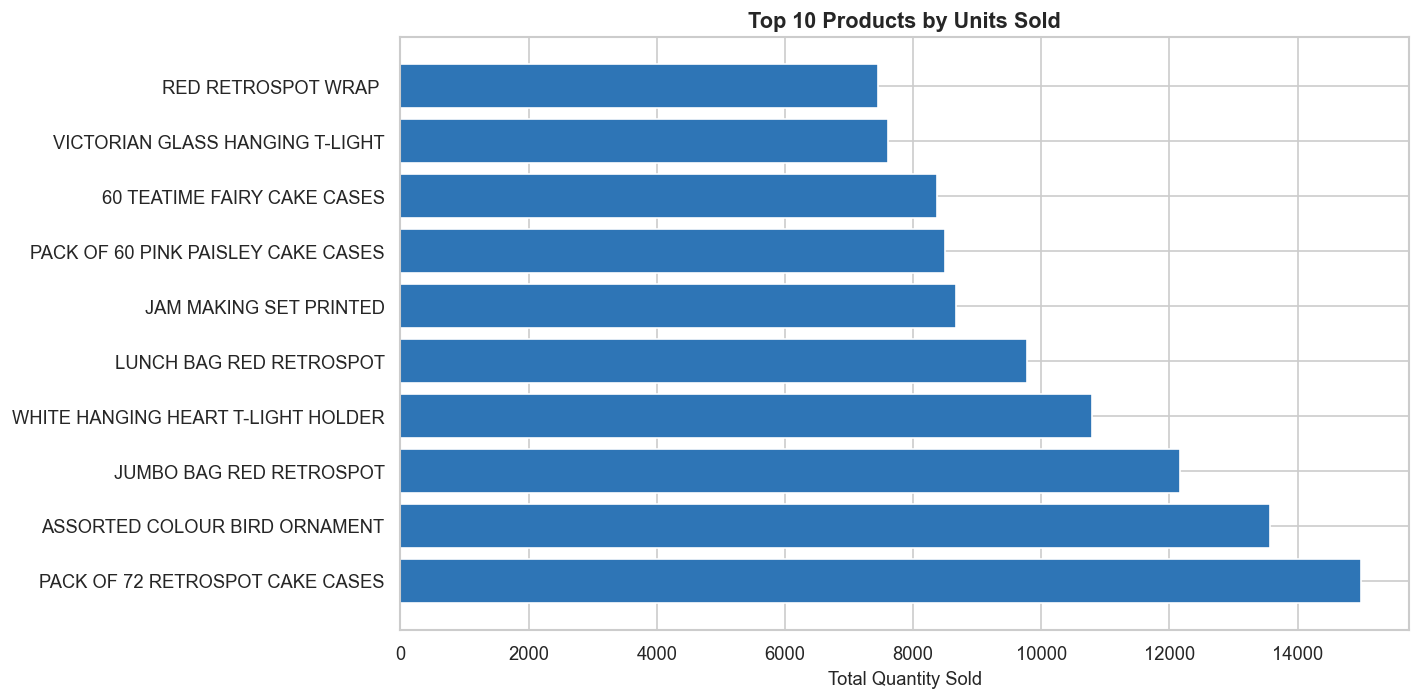

Insight: High-quantity products are not always high-revenue — unit price matters.


In [58]:
# ============================================================
# SECTION 4B: TOP 10 PRODUCTS BY UNITS SOLD
# ============================================================
top_qty = (df.groupby('Description')['Quantity']
             .sum()
             .nlargest(10)
             .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_qty['Description'], top_qty['Quantity'],
        color='#2E75B6', edgecolor='white')
ax.set_title('Top 10 Products by Units Sold')
ax.set_xlabel('Total Quantity Sold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_top_products_quantity.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Insight: High-quantity products are not always high-revenue — unit price matters.')

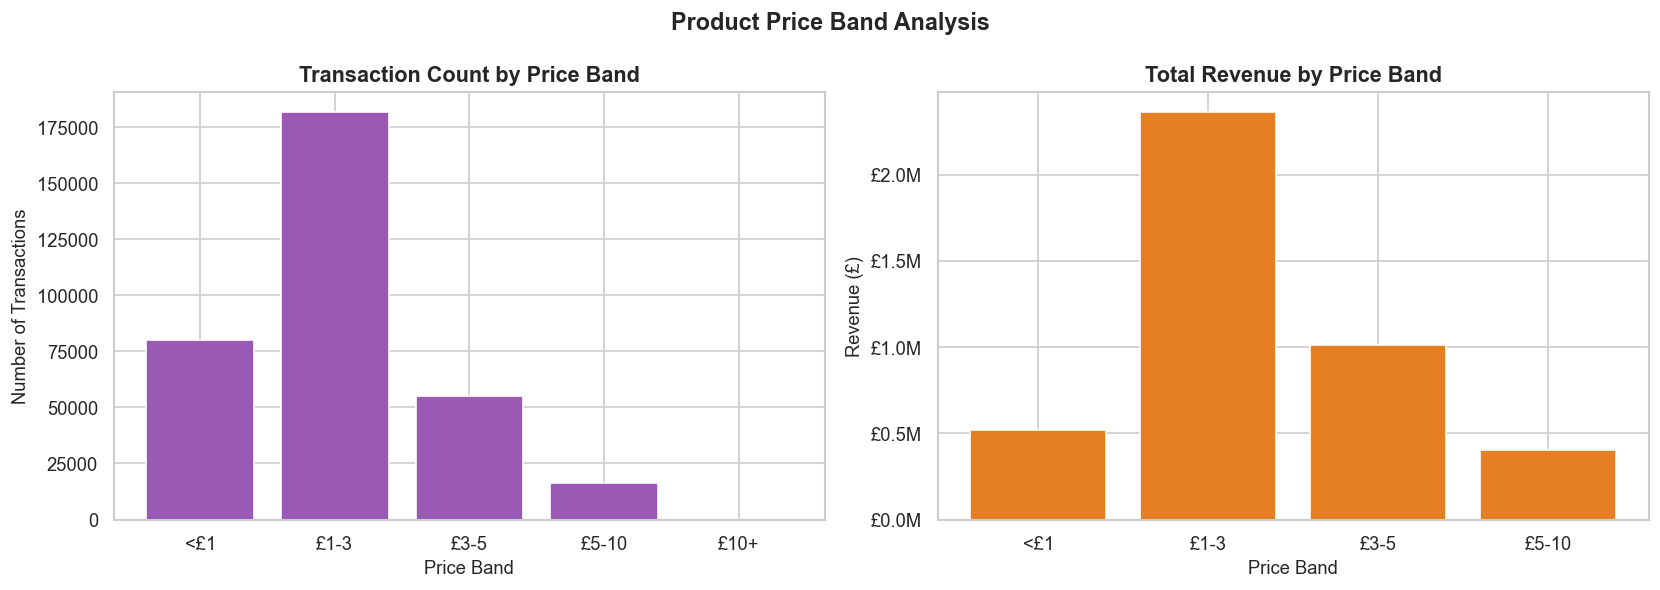

Insight: Mid-range £1-3 products drive the highest transaction volume.


In [59]:
# ============================================================
# SECTION 4C: PRODUCT PRICE DISTRIBUTION & SEGMENTS
# ============================================================
bins   = [0, 1, 3, 5, 10, 50]
labels = ['<£1', '£1-3', '£3-5', '£5-10', '£10+']
df['Price_Band'] = pd.cut(df['Price'], bins=bins, labels=labels)

price_band_rev   = df.groupby('Price_Band', observed=True)['Total_Revenue'].sum().reset_index()
price_band_count = df['Price_Band'].value_counts().reindex(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(price_band_count.index, price_band_count.values,
            color='#9B59B6', edgecolor='white')
axes[0].set_title('Transaction Count by Price Band')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xlabel('Price Band')

axes[1].bar(price_band_rev['Price_Band'], price_band_rev['Total_Revenue'],
            color='#E67E22', edgecolor='white')
axes[1].set_title('Total Revenue by Price Band')
axes[1].set_ylabel('Revenue (£)')
axes[1].set_xlabel('Price Band')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

plt.suptitle('Product Price Band Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_price_bands.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Mid-range £1-3 products drive the highest transaction volume.')

---
## Section 5 — Customer Analysis

Understanding customer behaviour — frequency, value distribution, and purchase patterns.

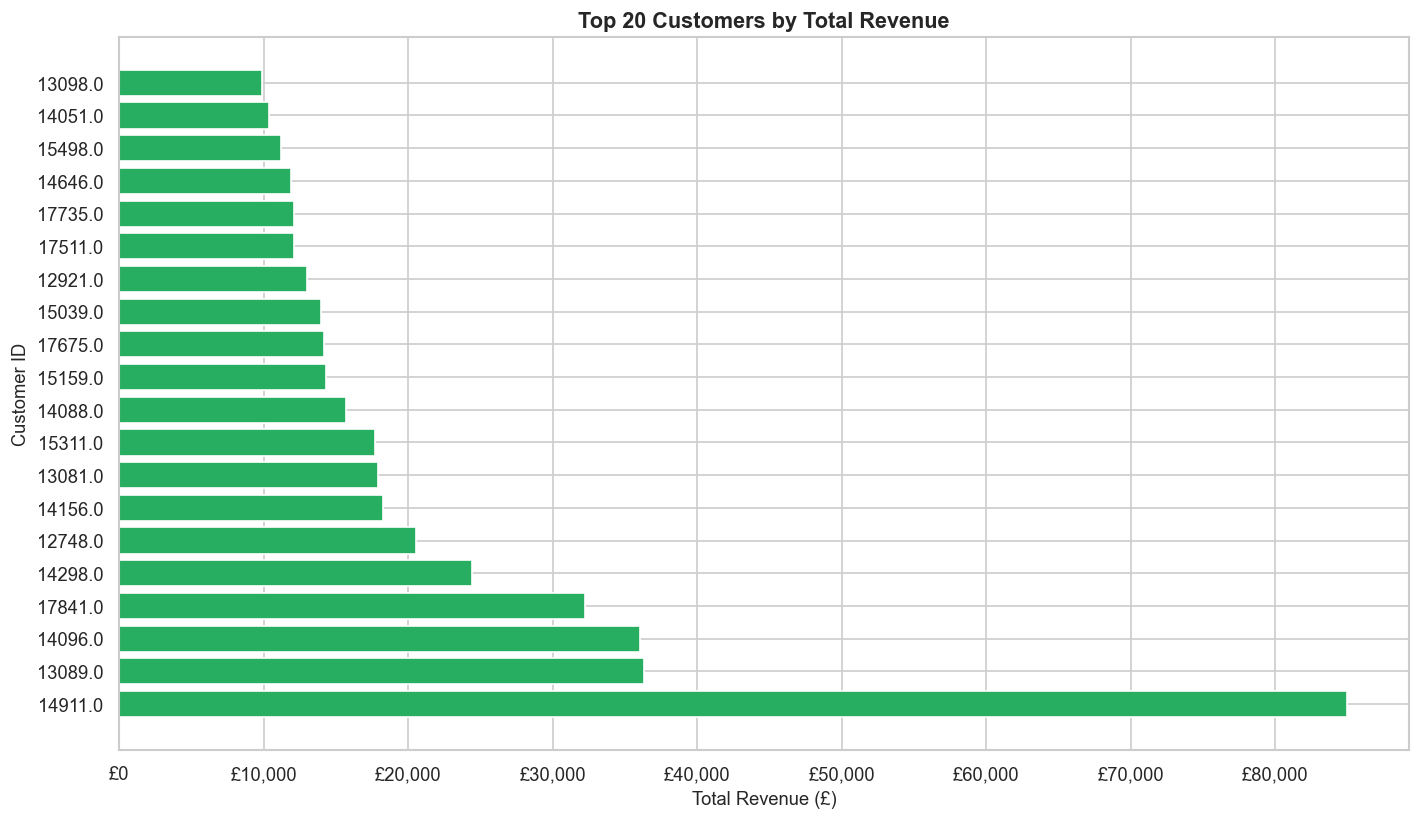

Top 20 customers contribute: 9.9% of total revenue
Insight: A small group of customers generate disproportionately high revenue (Pareto principle).


In [60]:
# ============================================================
# SECTION 5A: TOP 20 CUSTOMERS BY REVENUE
# ============================================================
top_customers = (df.groupby(customer_col)['Total_Revenue']
                   .sum()
                   .nlargest(20)
                   .reset_index())
top_customers[customer_col] = top_customers[customer_col].astype(str)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top_customers[customer_col], top_customers['Total_Revenue'],
        color='#27AE60', edgecolor='white')
ax.set_title('Top 20 Customers by Total Revenue')
ax.set_xlabel('Total Revenue (£)')
ax.set_ylabel('Customer ID')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_top_customers.png'), dpi=150, bbox_inches='tight')
plt.show()

total_rev = df['Total_Revenue'].sum()
top20_rev = top_customers['Total_Revenue'].sum()
print(f'Top 20 customers contribute: {top20_rev/total_rev*100:.1f}% of total revenue')
print('Insight: A small group of customers generate disproportionately high revenue (Pareto principle).')

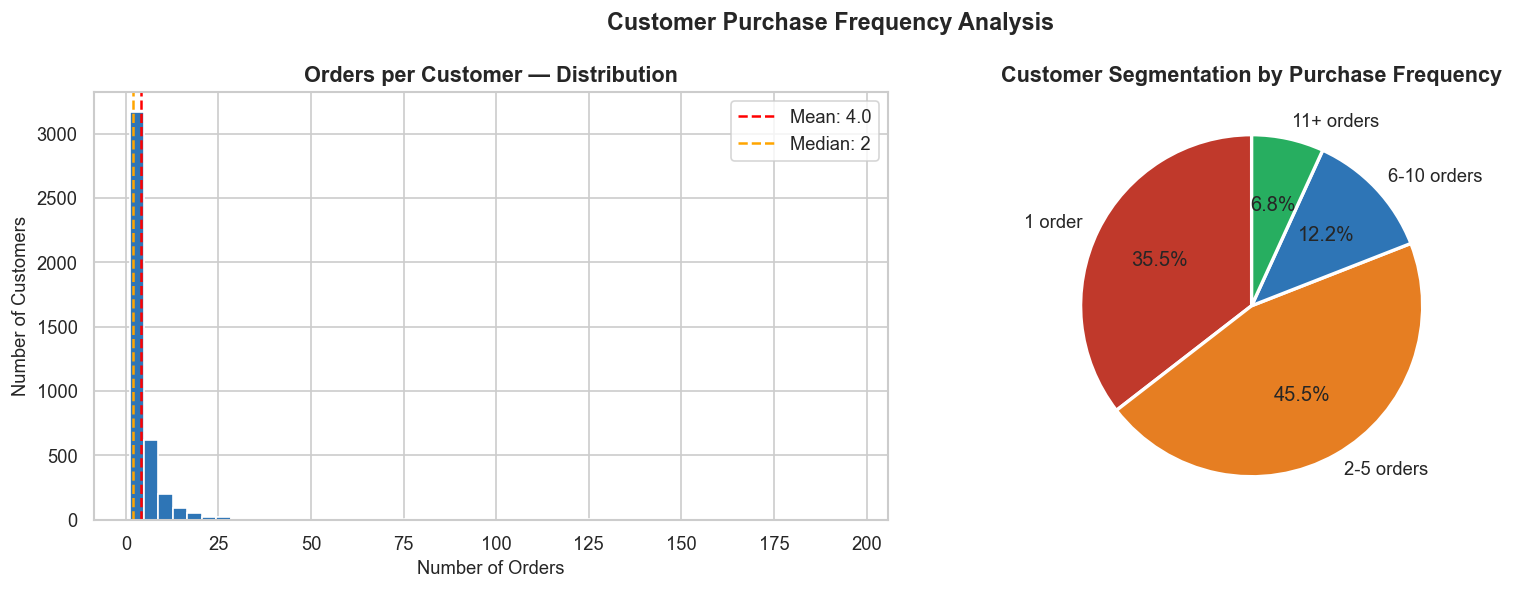

Average orders per customer : 4.0
Median orders per customer  : 2
Max orders by 1 customer    : 196
One-time customers          : 1,487 (35.5%)
Insight: Majority of customers are repeat buyers — loyalty is a key business driver.


In [61]:
# ============================================================
# SECTION 5B: CUSTOMER PURCHASE FREQUENCY DISTRIBUTION
# ============================================================
orders_per_customer = df.groupby(customer_col)[invoice_col].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(orders_per_customer, bins=50, color='#2E75B6', edgecolor='white')
axes[0].set_title('Orders per Customer — Distribution')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(orders_per_customer.mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {orders_per_customer.mean():.1f}')
axes[0].axvline(orders_per_customer.median(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Median: {orders_per_customer.median():.0f}')
axes[0].legend()

seg_labels = ['1 order', '2-5 orders', '6-10 orders', '11+ orders']
seg_counts = [
    (orders_per_customer == 1).sum(),
    ((orders_per_customer >= 2) & (orders_per_customer <= 5)).sum(),
    ((orders_per_customer >= 6) & (orders_per_customer <= 10)).sum(),
    (orders_per_customer >= 11).sum()
]
axes[1].pie(seg_counts, labels=seg_labels, autopct='%1.1f%%',
            colors=['#C0392B','#E67E22','#2E75B6','#27AE60'],
            startangle=90, wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Customer Segmentation by Purchase Frequency')

plt.suptitle('Customer Purchase Frequency Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_customer_frequency.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Average orders per customer : {orders_per_customer.mean():.1f}')
print(f'Median orders per customer  : {orders_per_customer.median():.0f}')
print(f'Max orders by 1 customer    : {orders_per_customer.max()}')
print(f'One-time customers          : {(orders_per_customer==1).sum():,} ({(orders_per_customer==1).sum()/len(orders_per_customer)*100:.1f}%)')
print('Insight: Majority of customers are repeat buyers — loyalty is a key business driver.')

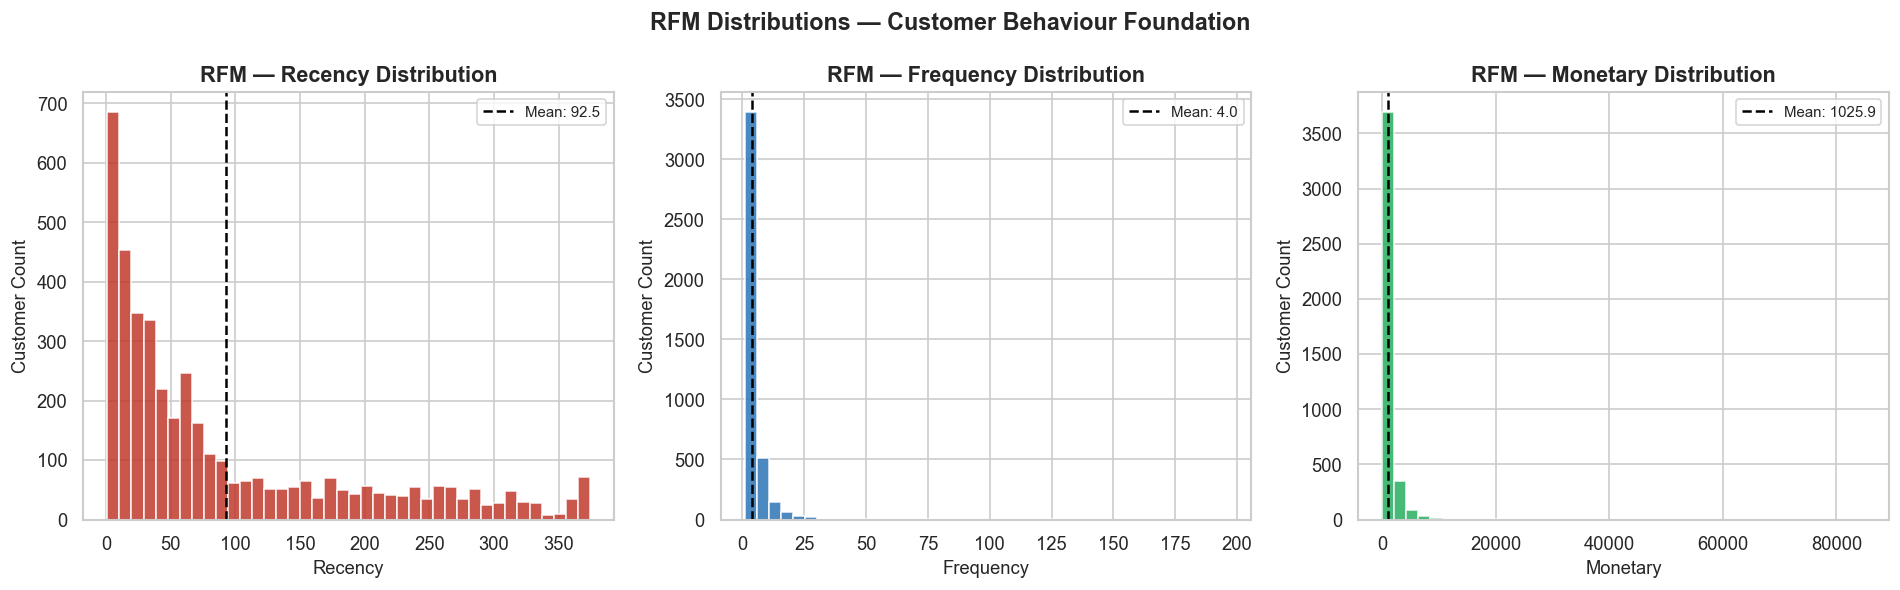

=== RFM SUMMARY STATISTICS ===


,Recency,Frequency,Monetary
count,4191.00,4191.00,4191.00
mean,92.49,4.01,1025.88
std,99.91,7.02,2200.19
min,1.00,1.00,1.90
25%,18.00,1.00,206.16
50%,51.00,2.00,465.97
75%,144.00,4.00,1127.34
max,374.00,196.00,84980.89



=== RFM METRIC INTERPRETATION ===
  RECENCY   : Days since the customer last made a purchase.
              Lower recency = more recently active. Mean = 92 days.
              High spread suggests a mix of active and lapsed customers.

  FREQUENCY : Number of unique invoices (orders) placed by the customer.
              Higher frequency = more loyal repeat buyer. Mean = 4.0 orders.
              Right-skewed — most customers order a small number of times.

  MONETARY  : Total revenue generated by the customer over the period.
              Higher monetary = higher-value customer. Mean = £1025.88.
              Large std dev indicates a wide range of customer value tiers.

Insight: RFM scores will feed directly into customer clustering in notebook 03.


In [62]:
# ============================================================
# SECTION 5C: RFM BASIS — RECENCY, FREQUENCY, MONETARY
# ADDITION: Detailed interpretation of each RFM metric added
# ============================================================
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby(customer_col).agg(
    Recency   = ('InvoiceDate',   lambda x: (reference_date - x.max()).days),
    Frequency = (invoice_col,     'nunique'),
    Monetary  = ('Total_Revenue', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
rfm_cols = ['Recency', 'Frequency', 'Monetary']
colors   = ['#C0392B', '#2E75B6', '#27AE60']

for ax, col, color in zip(axes, rfm_cols, colors):
    ax.hist(rfm[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'RFM — {col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Customer Count')
    ax.axvline(rfm[col].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {rfm[col].mean():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('RFM Distributions — Customer Behaviour Foundation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_rfm_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print('=== RFM SUMMARY STATISTICS ===')
display(rfm[['Recency','Frequency','Monetary']].describe().round(2))
print()
print('=== RFM METRIC INTERPRETATION ===')
print(f'  RECENCY   : Days since the customer last made a purchase.')
print(f'              Lower recency = more recently active. Mean = {rfm["Recency"].mean():.0f} days.')
print(f'              High spread suggests a mix of active and lapsed customers.')
print()
print(f'  FREQUENCY : Number of unique invoices (orders) placed by the customer.')
print(f'              Higher frequency = more loyal repeat buyer. Mean = {rfm["Frequency"].mean():.1f} orders.')
print(f'              Right-skewed — most customers order a small number of times.')
print()
print(f'  MONETARY  : Total revenue generated by the customer over the period.')
print(f'              Higher monetary = higher-value customer. Mean = £{rfm["Monetary"].mean():.2f}.')
print(f'              Large std dev indicates a wide range of customer value tiers.')
print()
print('Insight: RFM scores will feed directly into customer clustering in notebook 03.')

---
## Section 6 — Geographic Analysis

Understanding revenue distribution across countries to identify key markets.

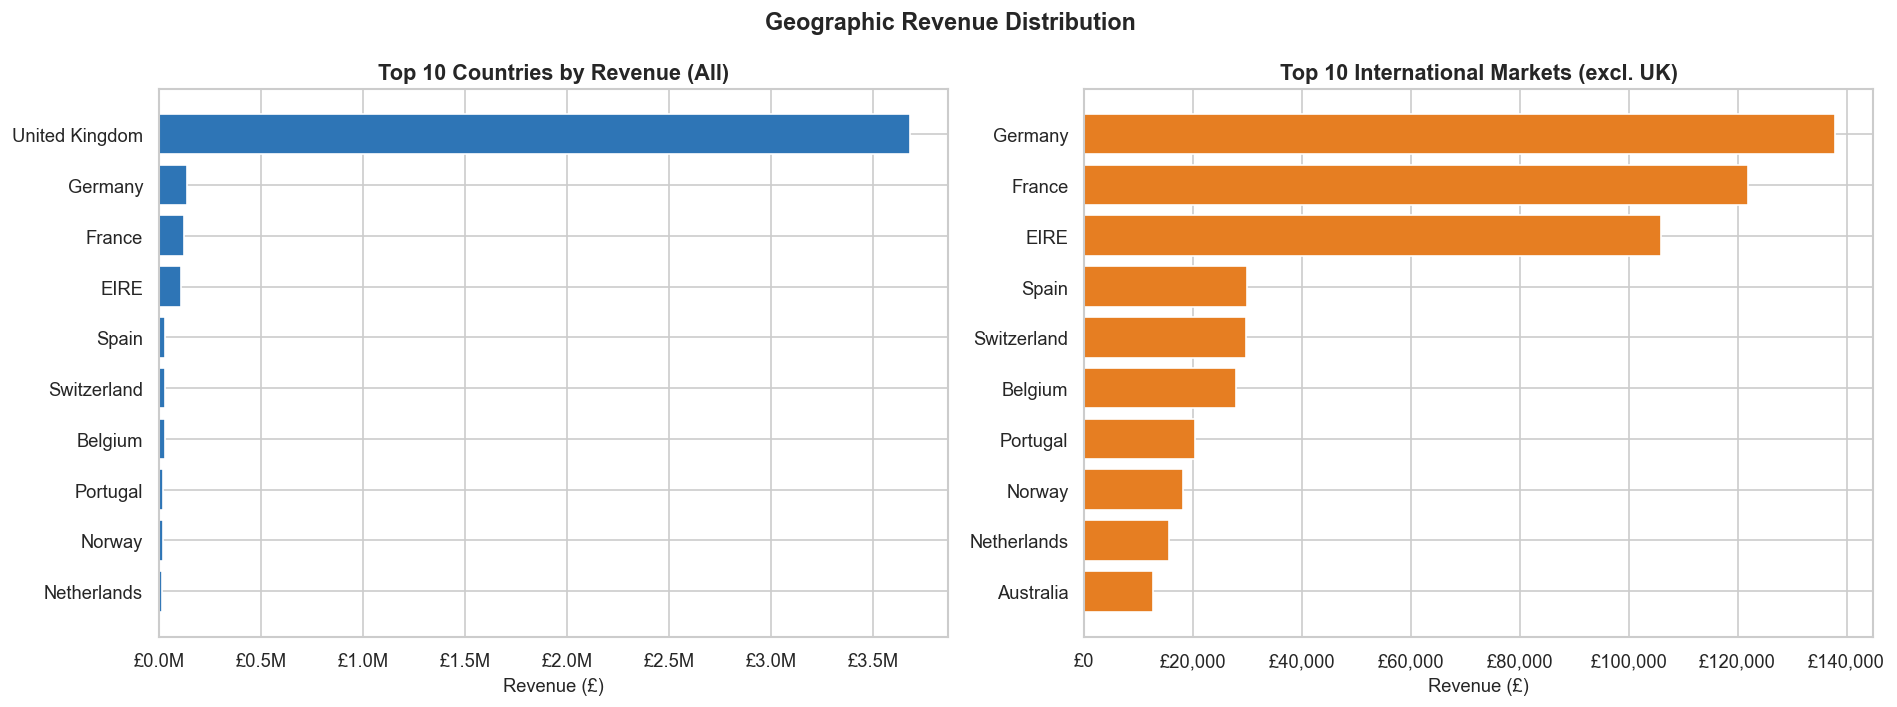

UK revenue share        : 85.6%
Top international market: Germany
Insight: UK dominates revenue. EIRE (Ireland) and Netherlands are top international markets.


In [63]:
# ============================================================
# SECTION 6A: REVENUE BY COUNTRY
# ============================================================
country_rev = df.groupby('Country').agg(
    Revenue      = ('Total_Revenue', 'sum'),
    Transactions = ('Total_Revenue', 'count'),
    Customers    = (customer_col, 'nunique')
).sort_values('Revenue', ascending=False)

top10_all  = country_rev.head(10)
top10_intl = country_rev[country_rev.index != 'United Kingdom'].head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10_all.index[::-1], top10_all['Revenue'][::-1],
             color='#2E75B6', edgecolor='white')
axes[0].set_title('Top 10 Countries by Revenue (All)')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

axes[1].barh(top10_intl.index[::-1], top10_intl['Revenue'][::-1],
             color='#E67E22', edgecolor='white')
axes[1].set_title('Top 10 International Markets (excl. UK)')
axes[1].set_xlabel('Revenue (£)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.suptitle('Geographic Revenue Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_geographic.png'), dpi=150, bbox_inches='tight')
plt.show()

uk_share = country_rev.loc['United Kingdom','Revenue'] / country_rev['Revenue'].sum() * 100
print(f'UK revenue share        : {uk_share:.1f}%')
print(f'Top international market: {top10_intl.index[0]}')
print('Insight: UK dominates revenue. EIRE (Ireland) and Netherlands are top international markets.')

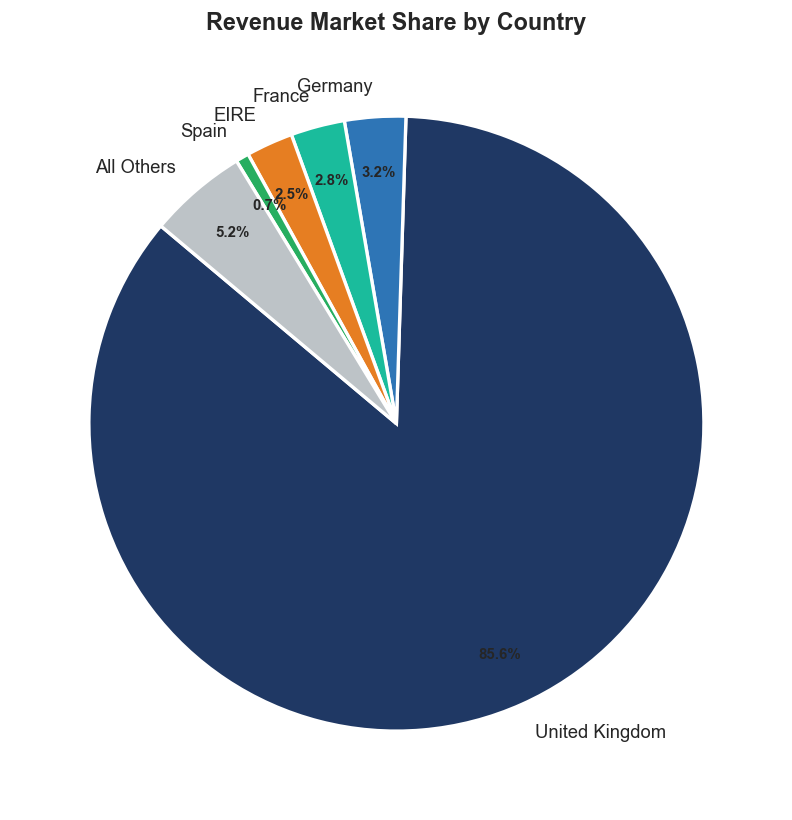

In [64]:
# ============================================================
# SECTION 6B: REVENUE MARKET SHARE PIE
# ============================================================
top5       = country_rev.head(5)
others_rev = country_rev.iloc[5:]['Revenue'].sum()
pie_data   = list(top5['Revenue']) + [others_rev]
pie_labels = list(top5.index) + ['All Others']
colors_pie = ['#1F3864','#2E75B6','#1ABC9C','#E67E22','#27AE60','#BDC3C7']

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    pie_data, labels=pie_labels, autopct='%1.1f%%',
    colors=colors_pie, startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2},
    pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax.set_title('Revenue Market Share by Country', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_market_share.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7 — Correlation Analysis

Identifying relationships between numerical variables to inform feature selection for modelling.

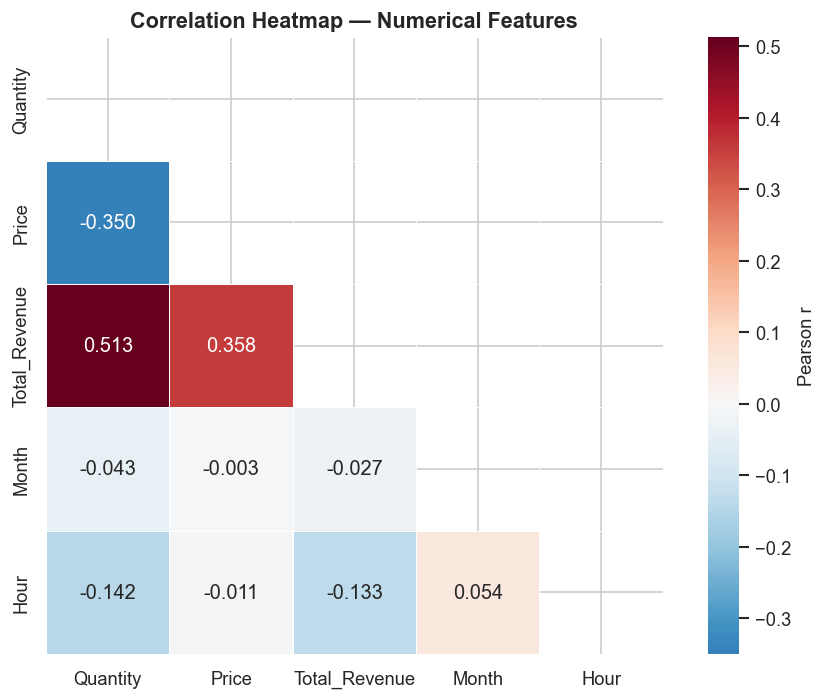

=== CORRELATION MATRIX ===
               Quantity  Price  Total_Revenue  Month   Hour
Quantity          1.000 -0.350          0.513 -0.043 -0.142
Price            -0.350  1.000          0.358 -0.003 -0.011
Total_Revenue     0.513  0.358          1.000 -0.027 -0.133
Month            -0.043 -0.003         -0.027  1.000  0.054
Hour             -0.142 -0.011         -0.133  0.054  1.000

Key Findings:
  Quantity vs Total_Revenue : 0.513  (strong positive)
  Price    vs Total_Revenue : 0.358  (moderate positive)
  Month    vs Revenue       : -0.027  (slight seasonal effect)
Insight: Quantity is the strongest driver of Total Revenue, more so than unit price.


In [65]:
# ============================================================
# SECTION 7A: CORRELATION HEATMAP
# FIX: mask is now correctly passed into sns.heatmap()
# ============================================================
numeric_cols = ['Quantity', 'Price', 'Total_Revenue', 'Month', 'Hour']
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            mask=mask,                                  # FIX: mask applied correctly
            cbar_kws={'label': 'Pearson r'},
            ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('=== CORRELATION MATRIX ===')
print(corr_matrix.round(3).to_string())
print()
print('Key Findings:')
print(f'  Quantity vs Total_Revenue : {corr_matrix.loc["Quantity","Total_Revenue"]:.3f}  (strong positive)')
print(f'  Price    vs Total_Revenue : {corr_matrix.loc["Price","Total_Revenue"]:.3f}  (moderate positive)')
print(f'  Month    vs Revenue       : {corr_matrix.loc["Month","Total_Revenue"]:.3f}  (slight seasonal effect)')
print('Insight: Quantity is the strongest driver of Total Revenue, more so than unit price.')

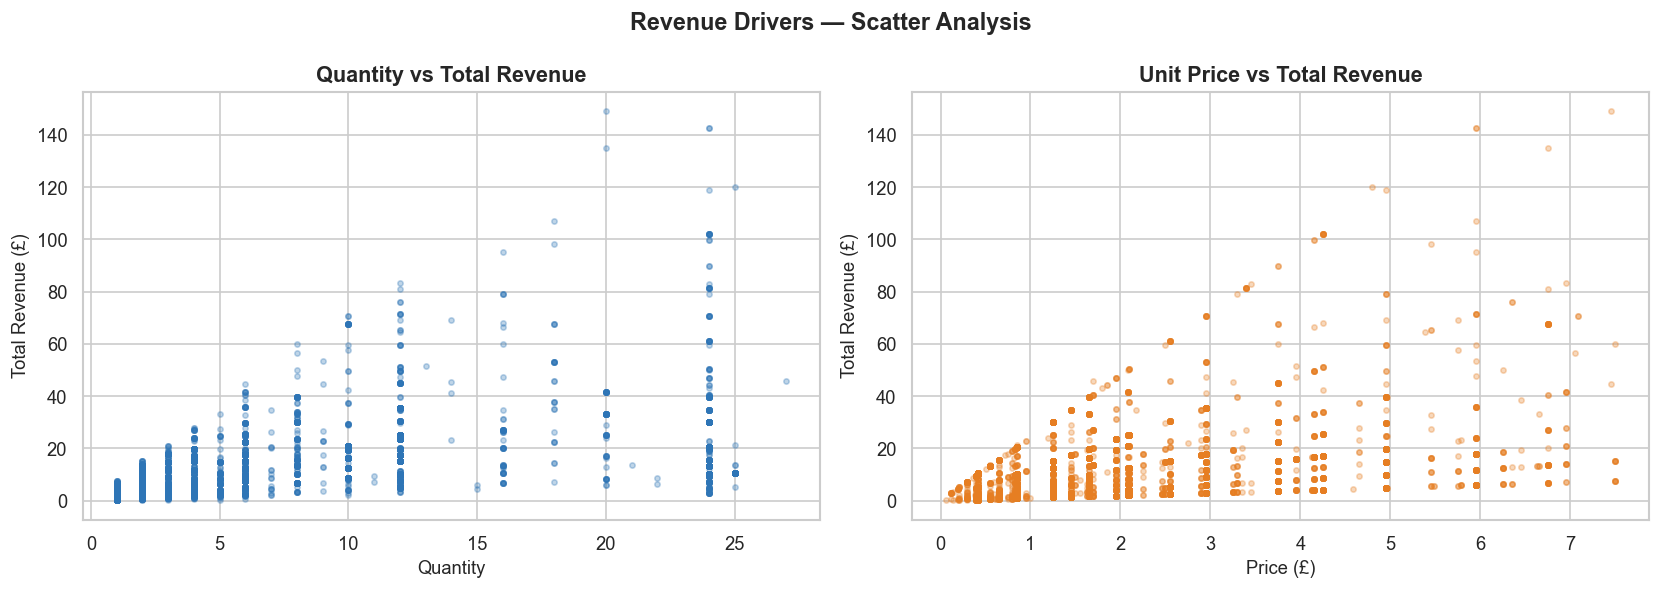

Insight: Positive linear relationship between Quantity and Revenue confirms high correlation.


In [66]:
# ============================================================
# SECTION 7B: SCATTER PLOTS — KEY RELATIONSHIPS
# ============================================================
sample = df.sample(min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['Quantity'], sample['Total_Revenue'],
                alpha=0.3, color='#2E75B6', s=10)
axes[0].set_title('Quantity vs Total Revenue')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Total Revenue (£)')

axes[1].scatter(sample['Price'], sample['Total_Revenue'],
                alpha=0.3, color='#E67E22', s=10)
axes[1].set_title('Unit Price vs Total Revenue')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Total Revenue (£)')

plt.suptitle('Revenue Drivers — Scatter Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_scatter_relationships.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Positive linear relationship between Quantity and Revenue confirms high correlation.')

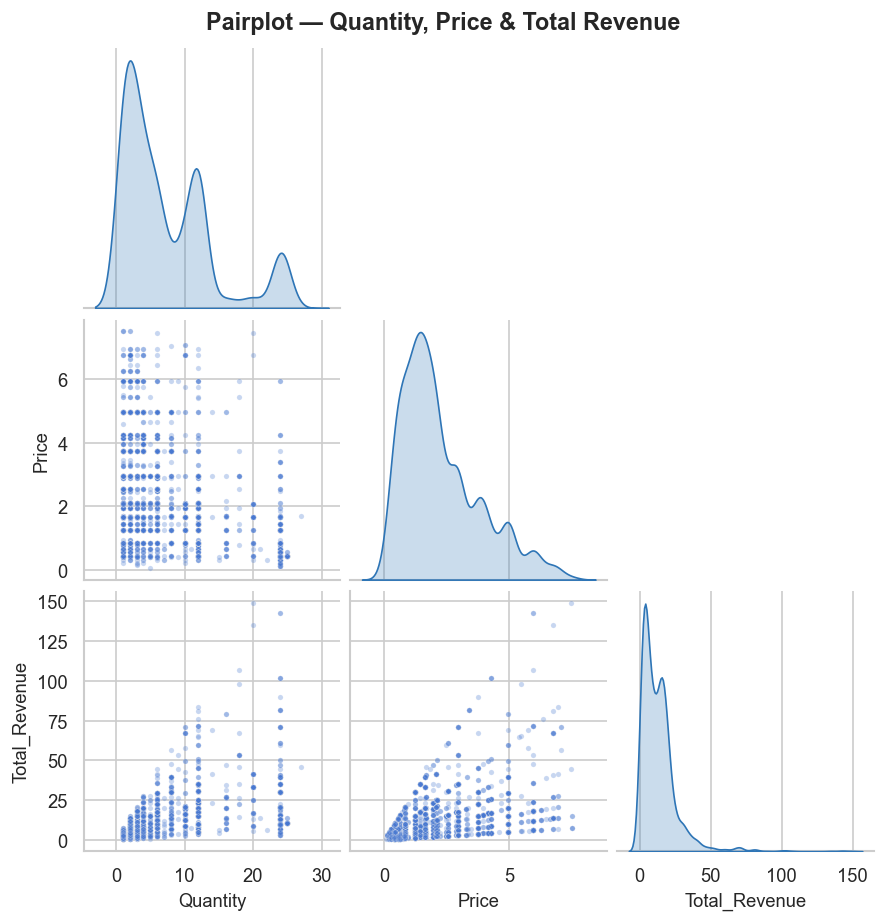

Insight: Pairplot confirms strong linear Quantity-Revenue relationship.
Insight: Price distribution is right-skewed — most products are low-cost items.
Insight: KDE diagonal plots show that all three variables are heavily right-skewed.


In [67]:
# ============================================================
# SECTION 7C: PAIRPLOT — QUANTITY, PRICE, TOTAL_REVENUE
# ADDITION: Shows distributions and pairwise relationships together
# ============================================================
sample_pair = df[['Quantity', 'Price', 'Total_Revenue']].sample(min(3000, len(df)), random_state=42)

pair_grid = sns.pairplot(
    sample_pair,
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kws={'color': '#2E75B6'}
)
pair_grid.figure.suptitle('Pairplot — Quantity, Price & Total Revenue',
                           y=1.02, fontsize=14, fontweight='bold')
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_pairplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Pairplot confirms strong linear Quantity-Revenue relationship.')
print('Insight: Price distribution is right-skewed — most products are low-cost items.')
print('Insight: KDE diagonal plots show that all three variables are heavily right-skewed.')

---
## Section 8 — Anomaly Detection

Identifying unusual patterns, outlying transactions, and anomalous behaviour in the dataset.

In [68]:
# ============================================================
# SECTION 8A: ANOMALY DETECTION — HIGH VALUE TRANSACTIONS
# ============================================================
threshold = df['Total_Revenue'].mean() + 3 * df['Total_Revenue'].std()
anomalies = df[df['Total_Revenue'] > threshold]

print(f'Anomaly threshold (mean + 3sigma): £{threshold:.2f}')
print(f'Anomalous transactions found      : {len(anomalies):,}  ({len(anomalies)/len(df)*100:.2f}% of dataset)')
print()
print('Top 10 Highest-Value Transactions:')
display(anomalies.nlargest(10, 'Total_Revenue')[
    ['InvoiceDate', 'Description', 'Quantity', 'Price', 'Total_Revenue', 'Country']
].reset_index(drop=True))

Anomaly threshold (mean + 3sigma): £52.55
Anomalous transactions found      : 6,320  (1.90% of dataset)

Top 10 Highest-Value Transactions:


,InvoiceDate,Description,Quantity,Price,Total_Revenue,Country
0,2011-09-06 09:51:00,SMALL DECO JEWELLERY STAND,24,7.45,178.80,United Kingdom
1,2011-10-05 10:11:00,WALL ART KEEP CALM,24,7.45,178.80,United Kingdom
2,2011-10-26 10:15:00,WALL ART CLASSIC PUDDINGS,24,7.45,178.80,United Kingdom
3,2011-10-28 10:56:00,WALL ART CLASSIC PUDDINGS,24,7.45,178.80,United Kingdom
4,2011-10-05 12:49:00,DOORMAT AIRMAIL,24,7.08,169.92,United Kingdom
5,2011-10-16 15:27:00,DOORMAT RED RETROSPOT,24,7.08,169.92,United Kingdom
6,2011-10-03 15:06:00,KEEP CALM WALL ART,24,6.98,167.52,United Kingdom
7,2010-12-17 10:32:00,WOOD S/3 CABINET ANT WHITE FINISH,24,6.95,166.80,United Kingdom
8,2011-01-18 10:41:00,WOOD S/3 CABINET ANT WHITE FINISH,24,6.95,166.80,United Kingdom
9,2011-03-18 10:03:00,3 HOOK PHOTO SHELF ANTIQUE WHITE,24,6.95,166.80,United Kingdom


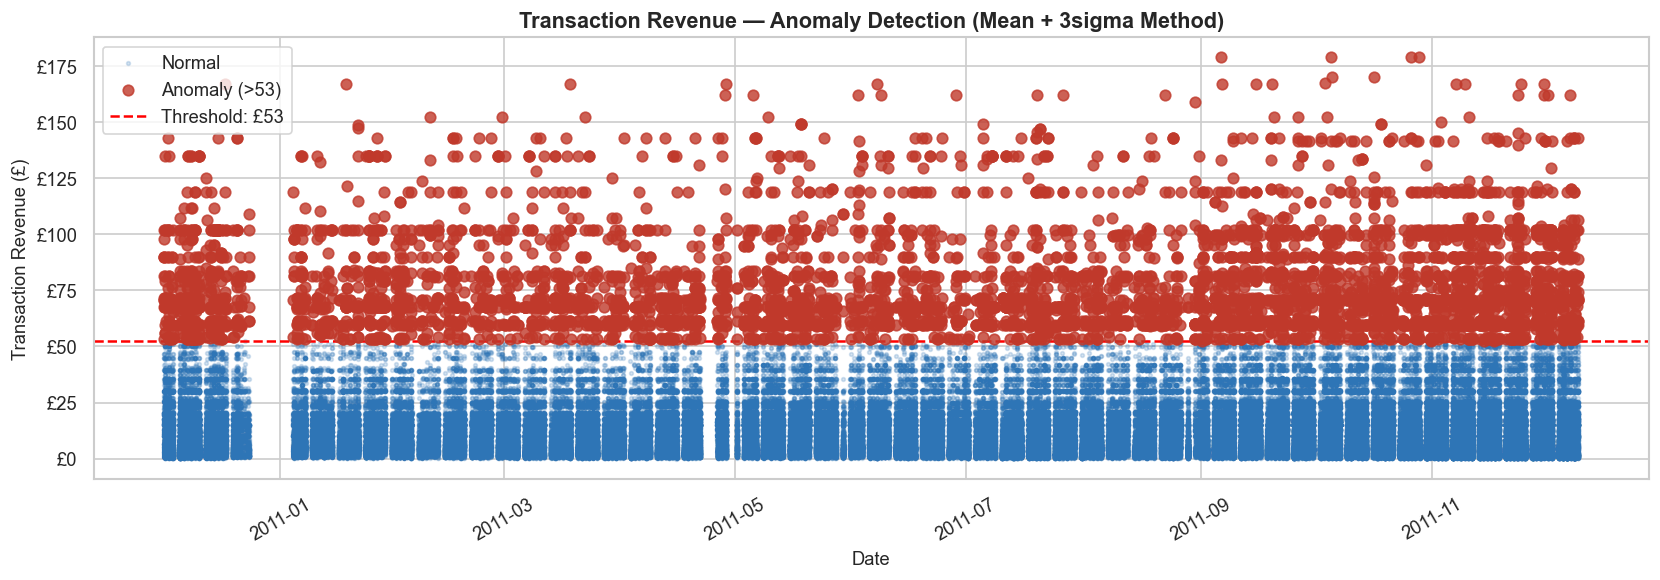

Insight: Anomalous transactions are concentrated in Nov 2011 — consistent with Q4 bulk orders.


In [69]:
# ============================================================
# SECTION 8B: ANOMALY VISUALISATION
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

normal = df[df['Total_Revenue'] <= threshold]
ax.scatter(normal['InvoiceDate'], normal['Total_Revenue'],
           alpha=0.2, s=5, color='#2E75B6', label='Normal')
ax.scatter(anomalies['InvoiceDate'], anomalies['Total_Revenue'],
           alpha=0.8, s=40, color='#C0392B', label=f'Anomaly (>{threshold:.0f})', zorder=5)
ax.axhline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold: £{threshold:.0f}')

ax.set_title('Transaction Revenue — Anomaly Detection (Mean + 3sigma Method)')
ax.set_xlabel('Date')
ax.set_ylabel('Transaction Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_anomalies.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Anomalous transactions are concentrated in Nov 2011 — consistent with Q4 bulk orders.')

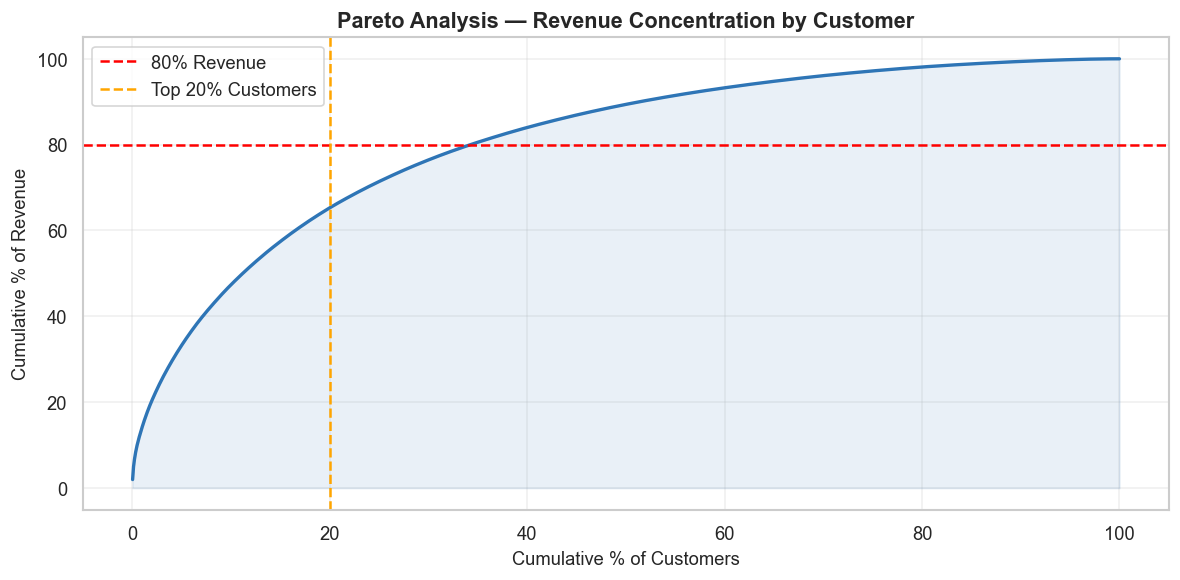

34.3% of customers generate 80% of total revenue.
Insight: Classic Pareto principle — a small customer segment is highly valuable.


In [70]:
# ============================================================
# SECTION 8C: REVENUE CONCENTRATION — PARETO ANALYSIS
# ============================================================
cust_rev       = df.groupby(customer_col)['Total_Revenue'].sum().sort_values(ascending=False)
cumulative_pct = cust_rev.cumsum() / cust_rev.sum() * 100
customer_pct   = np.arange(1, len(cust_rev)+1) / len(cust_rev) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(customer_pct, cumulative_pct.values, color='#2E75B6', linewidth=2)
ax.axhline(80, color='red',    linestyle='--', linewidth=1.5, label='80% Revenue')
ax.axvline(20, color='orange', linestyle='--', linewidth=1.5, label='Top 20% Customers')
ax.fill_between(customer_pct, cumulative_pct.values, alpha=0.1, color='#2E75B6')
ax.set_title('Pareto Analysis — Revenue Concentration by Customer', fontweight='bold')
ax.set_xlabel('Cumulative % of Customers')
ax.set_ylabel('Cumulative % of Revenue')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_pareto.png'), dpi=150, bbox_inches='tight')
plt.show()

idx_80 = np.searchsorted(cumulative_pct.values, 80)
pct_customers_for_80 = customer_pct[idx_80]
print(f'{pct_customers_for_80:.1f}% of customers generate 80% of total revenue.')
print('Insight: Classic Pareto principle — a small customer segment is highly valuable.')

---
## Section 9 — Key Operational & Customer Insights Summary

This section consolidates all findings into actionable business intelligence.

> **Note:** Run all sections above (1–8) before executing this section, as it depends on variables computed in earlier cells.

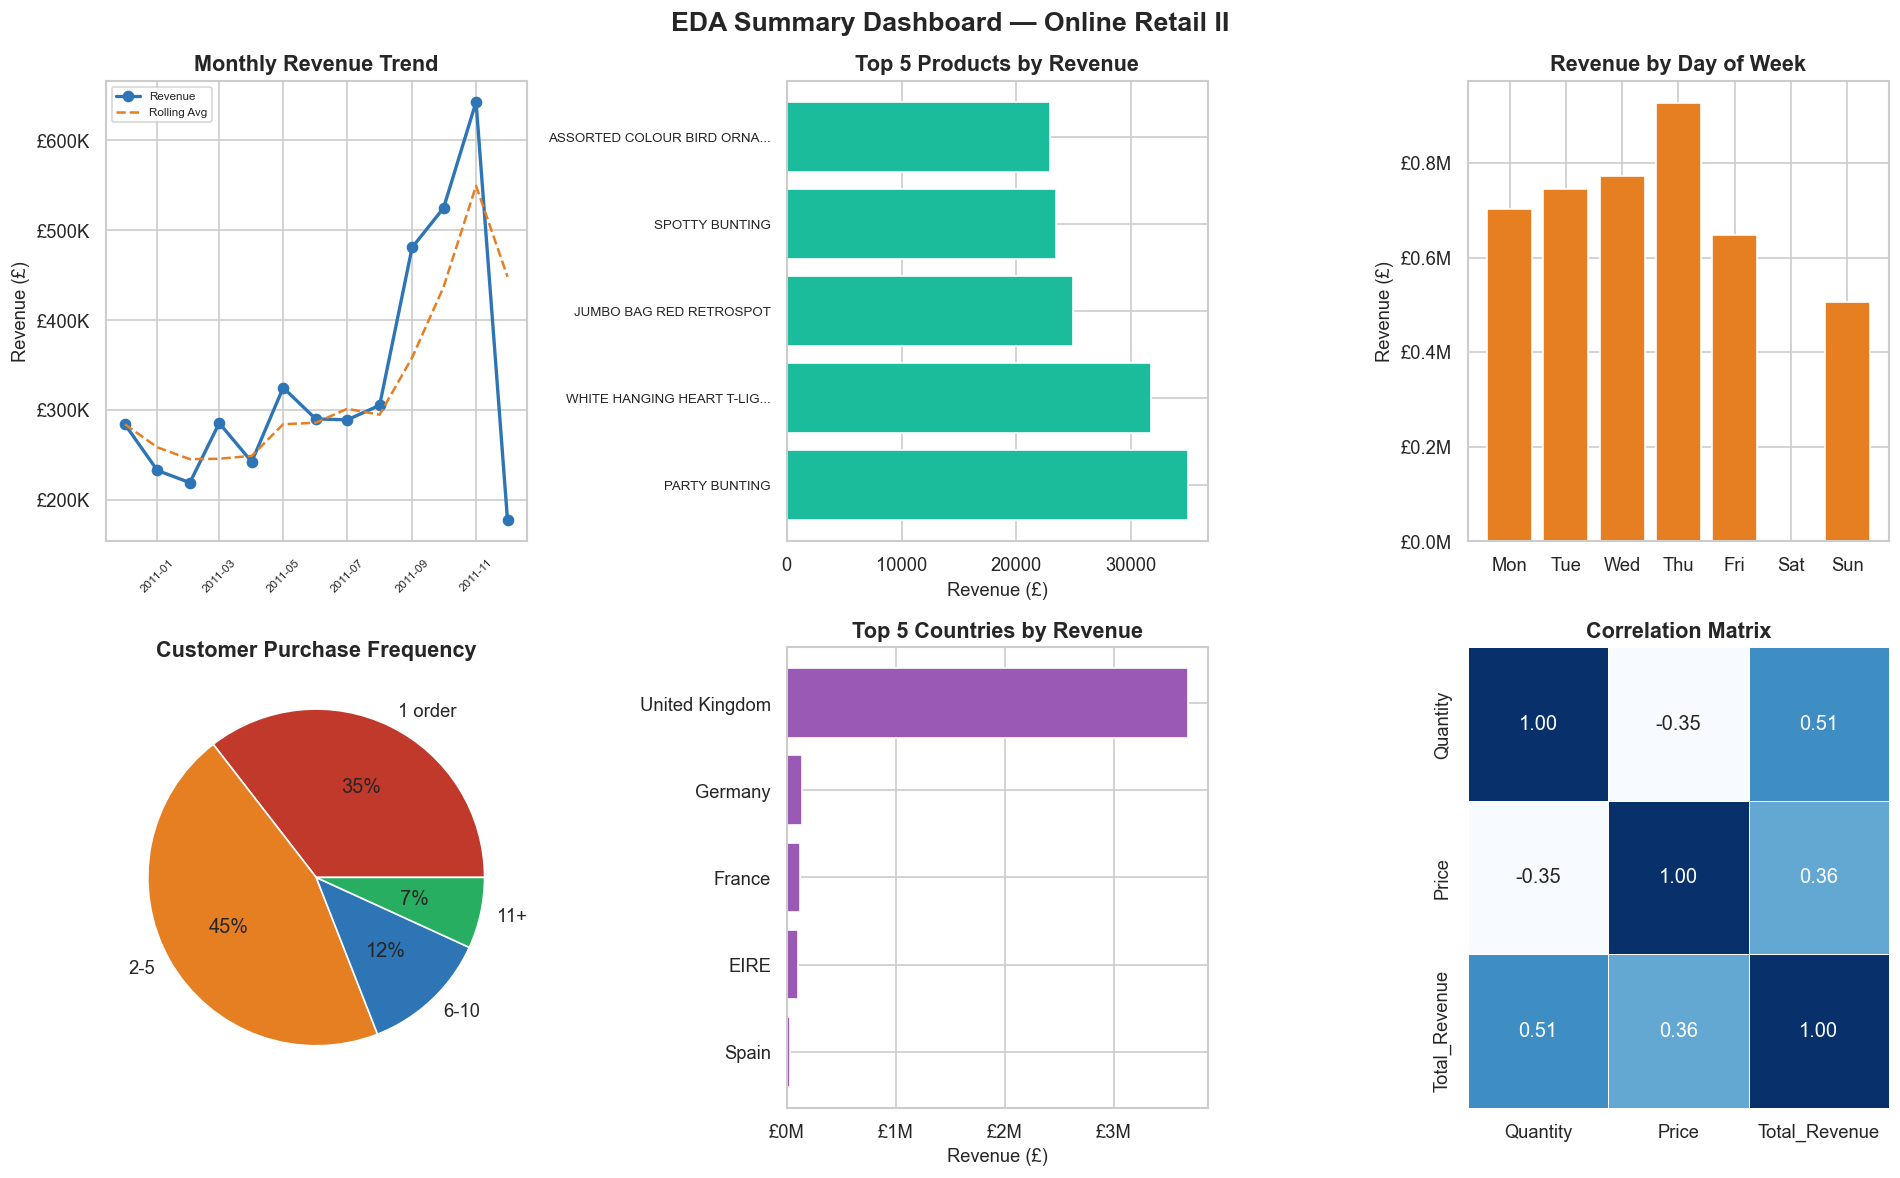

Summary dashboard saved: eda_summary_dashboard.png


In [71]:
# ============================================================
# SECTION 9A: KEY INSIGHTS SUMMARY DASHBOARD
# NOTE: Requires variables from Sections 3-8 to be run first
# ============================================================
fig = plt.figure(figsize=(16, 10))
fig.suptitle('EDA Summary Dashboard — Online Retail II', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Monthly Revenue + Rolling Avg
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(monthly_rev['InvoiceDate'], monthly_rev['Total_Revenue'],
         marker='o', color='#2E75B6', linewidth=2, label='Revenue')
ax1.plot(monthly_rev['InvoiceDate'], monthly_rev['Rolling_Avg'],
         color='#E67E22', linewidth=1.5, linestyle='--', label='Rolling Avg')
ax1.set_title('Monthly Revenue Trend')
ax1.set_ylabel('Revenue (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e3:.0f}K'))
ax1.legend(fontsize=7)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, fontsize=7)

# Plot 2: Top 5 Products
ax2 = fig.add_subplot(2, 3, 2)
top5_prod = df.groupby('Description')['Total_Revenue'].sum().nlargest(5)
ax2.barh(range(5), top5_prod.values, color='#1ABC9C', edgecolor='white')
ax2.set_yticks(range(5))
ax2.set_yticklabels([t[:25]+'...' if len(t)>25 else t for t in top5_prod.index], fontsize=8)
ax2.set_title('Top 5 Products by Revenue')
ax2.set_xlabel('Revenue (£)')

# Plot 3: Revenue by Day
ax3 = fig.add_subplot(2, 3, 3)
day_short = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_full  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_vals  = df.groupby('DayOfWeek')['Total_Revenue'].sum().reindex(day_full)
ax3.bar(day_short, day_vals.values, color='#E67E22', edgecolor='white')
ax3.set_title('Revenue by Day of Week')
ax3.set_ylabel('Revenue (£)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.1f}M'))

# Plot 4: Customer Frequency Pie
ax4 = fig.add_subplot(2, 3, 4)
ax4.pie(seg_counts, labels=['1 order','2-5','6-10','11+'],
        autopct='%1.0f%%', colors=['#C0392B','#E67E22','#2E75B6','#27AE60'],
        wedgeprops={'edgecolor':'white'})
ax4.set_title('Customer Purchase Frequency')

# Plot 5: Top 5 Countries
ax5 = fig.add_subplot(2, 3, 5)
top5_countries = country_rev.head(5)
ax5.barh(top5_countries.index[::-1], top5_countries['Revenue'][::-1],
         color='#9B59B6', edgecolor='white')
ax5.set_title('Top 5 Countries by Revenue')
ax5.set_xlabel('Revenue (£)')
ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1e6:.0f}M'))

# Plot 6: Correlation heatmap (mini)
ax6 = fig.add_subplot(2, 3, 6)
sns.heatmap(
    corr_matrix[['Quantity','Price','Total_Revenue']].loc[['Quantity','Price','Total_Revenue']],
    annot=True, fmt='.2f', cmap='Blues', ax=ax6,
    linewidths=0.5, cbar=False
)
ax6.set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_FOLDER, 'eda_summary_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Summary dashboard saved: eda_summary_dashboard.png')

In [72]:
# ============================================================
# SECTION 9B: PRINTED INSIGHTS REPORT
# ============================================================
print('=' * 65)
print('   KEY OPERATIONAL & CUSTOMER INSIGHTS - EDA FINDINGS')
print('=' * 65)

print('\nPRODUCT INSIGHTS')
print(f'  Top product by revenue : {top_products.iloc[0]["Description"]}')
print(f'  Total unique products  : {df["StockCode"].nunique():,}')
print(f'  Mid-range 1-3 items drive the highest transaction volume')

print('\nCUSTOMER INSIGHTS')
print(f'  Total unique customers : {df[customer_col].nunique():,}')
print(f'  Avg orders/customer    : {orders_per_customer.mean():.1f}')
print(f'  Top 20 customers generate {top20_rev/total_rev*100:.1f}% of total revenue')
print(f'  {pct_customers_for_80:.0f}% of customers generate 80% of revenue (Pareto)')

print('\nTEMPORAL INSIGHTS')
print(f'  Peak revenue month : {peak_month}')
print(f'  Best day of week   : {day_rev.idxmax()}')
print(f'  Peak hour          : {peak_hour}:00 - {peak_hour+1}:00')
print(f'  Strong Q4 seasonality (Oct-Nov) - pre-Christmas demand spike')

print('\nGEOGRAPHIC INSIGHTS')
print(f'  UK market share    : {uk_share:.1f}% of total revenue')
print(f'  Top intl market    : {top10_intl.index[0]}')
print(f'  Total countries    : {df["Country"].nunique()}')

print('\nSTATISTICAL INSIGHTS')
print(f'  Total Revenue      : £{df["Total_Revenue"].sum():,.2f}')
print(f'  Anomalies detected : {len(anomalies):,} transactions (>£{threshold:.0f})')
print(f'  Quantity-Revenue correlation: {corr_matrix.loc["Quantity","Total_Revenue"]:.3f} (strong)')

print('\nBUSINESS RECOMMENDATIONS')
print('  1. Focus marketing on October-November for maximum seasonal impact')
print('  2. Prioritise retention of top 20% high-value customers')
print('  3. Expand international marketing in EIRE and Netherlands')
print('  4. Schedule promotions between 10am-3pm on Thursday for peak engagement')
print('  5. Investigate Q4 bulk-order anomalies for potential B2B segment strategy')
print()
print('=' * 65)
print('EDA COMPLETE - All charts saved to reports/ folder')
print('=' * 65)

   KEY OPERATIONAL & CUSTOMER INSIGHTS - EDA FINDINGS

PRODUCT INSIGHTS
  Top product by revenue : PARTY BUNTING
  Total unique products  : 3,392
  Mid-range 1-3 items drive the highest transaction volume

CUSTOMER INSIGHTS
  Total unique customers : 4,191
  Avg orders/customer    : 4.0
  Top 20 customers generate 9.9% of total revenue
  34% of customers generate 80% of revenue (Pareto)

TEMPORAL INSIGHTS
  Peak revenue month : November 2011
  Best day of week   : Thursday
  Peak hour          : 12:00 - 13:00
  Strong Q4 seasonality (Oct-Nov) - pre-Christmas demand spike

GEOGRAPHIC INSIGHTS
  UK market share    : 85.6% of total revenue
  Top intl market    : Germany
  Total countries    : 37

STATISTICAL INSIGHTS
  Total Revenue      : £4,299,476.18
  Anomalies detected : 6,320 transactions (>£53)
  Quantity-Revenue correlation: 0.513 (strong)

BUSINESS RECOMMENDATIONS
  1. Focus marketing on October-November for maximum seasonal impact
  2. Prioritise retention of top 20% high-value 